In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import models, layers, Sequential
import matplotlib.pyplot as plt
import numpy as np


ModuleNotFoundError: No module named 'matplotlib'

In [ ]:
IMG_SIZE = 256
BATCH_SIZE = 32
CHANNELS = 3

In [ ]:
dataset = keras.utils.image_dataset_from_directory(
    '/content/drive/MyDrive/datasets/dataset',
    shuffle = True,
    image_size = (IMG_SIZE, IMG_SIZE),
    batch_size = BATCH_SIZE
)

Found 2152 files belonging to 3 classes.


In [ ]:
class_names  = dataset.class_names
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [ ]:
print("Length of dataset: 2152/32 =",2152/32)

Length of dataset: 2152/32 = 67.25


In [ ]:
len(dataset)

68

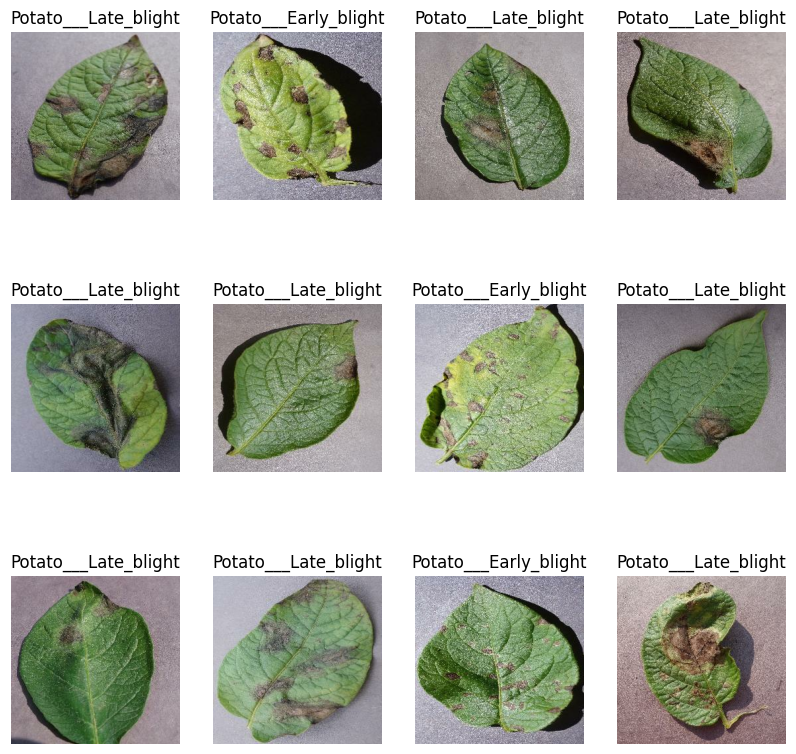

In [ ]:
plt.figure(figsize=(10, 10))
for image_batch, label_batch in dataset.take(1):

    for i in range(12):
        # print(image_batch[0].numpy().shape)
        # print(label_batch[0].numpy()) #label of every image of this batch

        plt.subplot(3,4, i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[label_batch[i]])
        plt.axis("off")


In [ ]:
len(dataset)

68

- 80% ==> training
- 20% ==> 10% validation, 10% test

In [ ]:
train_size = 0.8

len(dataset)*0.8

54.400000000000006

In [ ]:
train_ds = dataset.take(54)
len(train_ds)

54

In [ ]:
test_ds = dataset.skip(54)
len(test_ds)

14

In [ ]:
val_size = 0.1

len(dataset)*val_size

6.800000000000001

In [ ]:
val_ds = test_ds.take(6)
test_ds = test_ds.skip(6)

In [ ]:
# Now convert that into a function
def get_dataset_partition_tf(ds, train_split=0.8, test_split=0.1, val_split=0.1, shuffle=True, shuffle_size=10000):

    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)
    ds_size = len(ds)

    train_size = int(train_split*ds_size)
    val_size = int(val_split*ds_size)

    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)

    return train_ds, val_ds, test_ds


In [ ]:
train_ds, val_ds, test_ds = get_dataset_partition_tf(dataset)

In [ ]:
print(len(train_ds))
print(len(val_ds))
print(len(test_ds))

54
6
8


 - `.cache()` is used to store your dataset in memory (or disk) after the first iteration, so that future epochs are much faster.
 - `.prefetch()` lets your model prepare the next batch while the current batch is training.


In [ ]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [ ]:
resize_and_rescale = keras.Sequential([
    keras.layers.Resizing(IMG_SIZE, IMG_SIZE),
    keras.layers.Rescaling(1.0/255)
])

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.2),
])

In [ ]:
n_classes = 3
input_shape = (IMG_SIZE, IMG_SIZE,CHANNELS)

model = models.Sequential([

    layers.Input(shape=input_shape),

    resize_and_rescale,
    data_augmentation,

    layers.Conv2D(32, kernel_size= (3, 3), activation='relu'),
    layers.MaxPool2D((2, 2)),

    layers.Conv2D(64, kernel_size= (3, 3), activation='relu'),
    layers.MaxPool2D((2, 2)),

    layers.Conv2D(64, kernel_size= (3, 3), activation='relu'),
    layers.MaxPool2D((2, 2)),

    layers.Conv2D(64, kernel_size= (3, 3), activation='relu'),
    layers.MaxPool2D((2, 2)),

    layers.Conv2D(64, kernel_size= (3, 3), activation='relu'),
    layers.MaxPool2D((2, 2)),

    layers.Conv2D(64, kernel_size= (3, 3), activation='relu'),
    layers.MaxPool2D((2, 2)),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax')
])


In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,747 (717.76 KB)

 Trainable params: 183,747 (717.76 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [ ]:
!nvidia-smi

Fri Apr 17 10:28:52 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   71C    P0             30W /   70W |     141MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
EPOCHS = 50

history = model.fit(
    train_ds,
    epochs = EPOCHS,
    validation_data = val_ds
)

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 34s 214ms/step - accuracy: 0.4959 - loss: 0.8995 - val_accuracy: 0.4375 - val_loss: 0.8683
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.5961 - loss: 0.7611 - val_accuracy: 0.6823 - val_loss: 0.7434
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.7674 - loss: 0.5213 - val_accuracy: 0.7917 - val_loss: 0.3974
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.8553 - loss: 0.3662 - val_accuracy: 0.8281 - val_loss: 0.3743
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.8571 - loss: 0.3494 - val_accuracy: 0.7708 - val_loss: 0.4850
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.8924 - loss: 0.2596 - val_accuracy: 0.7396 - val_loss: 0.5563
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.9300 - loss: 0.1826 - val_accuracy: 0.7188 - val_loss: 0.8088
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.8872 - loss: 0.2833 - val_accuracy: 0.8750 -

In [ ]:
scores = model.evaluate(test_ds)

8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 1.0000 - loss: 0.0031


In [ ]:
scores

[0.003056416753679514, 1.0]

In [ ]:
history

In [ ]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

Text(0.5, 1.0, 'Training and Validation accuracy')

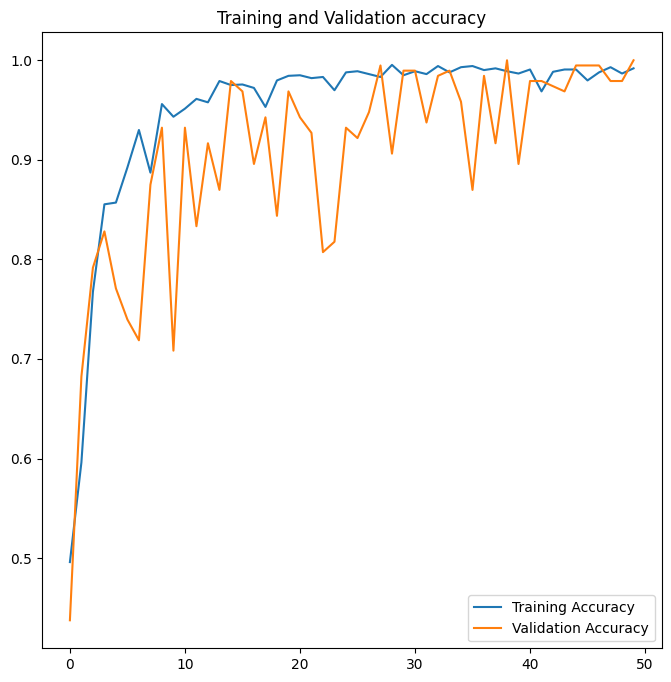

In [ ]:
plt.figure(figsize=(8, 8))
plt.plot(range(EPOCHS), acc, label = 'Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation accuracy')

Text(0.5, 1.0, 'Training and Validation Loss')

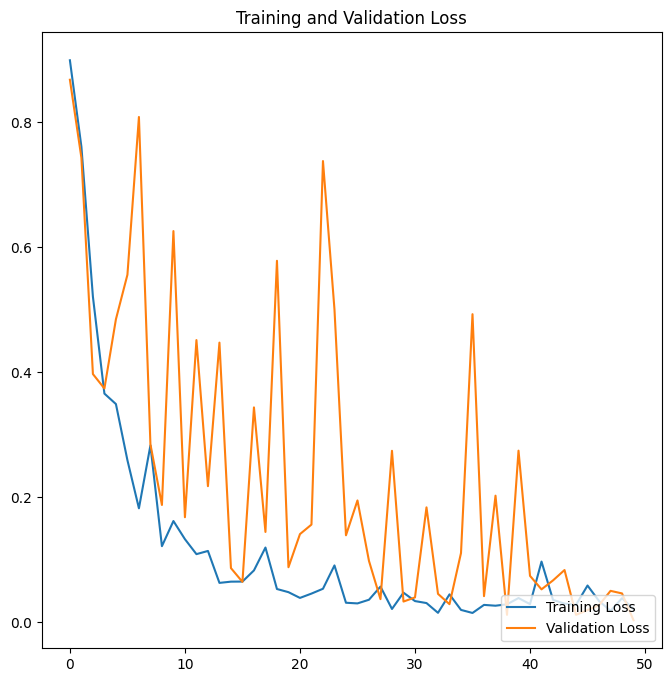

In [ ]:
plt.figure(figsize=(8, 8))
plt.plot(range(EPOCHS), loss, label = 'Training Loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
plt.legend(loc='lower right')
plt.title('Training and Validation Loss')

In [ ]:
# First check what Colab is using — run this in Colab
import keras, tensorflow as tf
print(keras.__version__)
print(tf.__version__)

3.13.2
2.19.0


In [ ]:
model.save("potato-disease-classifier-2.keras")

In [ ]:
np.argmax([9.9994385e-01, 5.6096465e-05, 9.6093902e-14])

np.int64(0)

First image to predict: 
Actual label:  Potato___Early_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
PredictedLabel:  Potato___Early_blight


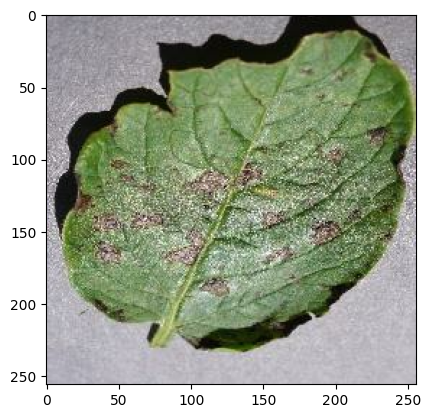

In [ ]:
for images_batch, labels_batch in test_ds.take(1):

  # plt.imshow(images_batch[0].numpy().astype('uint8'))
  first_image = images_batch[0].numpy().astype('uint8')
  # print(labels_batch[0])
  first_label = labels_batch[0].numpy()

  print('First image to predict: ')
  plt.imshow(first_image)
  print("Actual label: ", class_names[first_label])

  batch_prediction = model.predict(images_batch)
  print("PredictedLabel: ", class_names[np.argmax(batch_prediction[0])])


In [ ]:
def predict(model, img):
  img_array = keras.preprocessing.image.img_to_array(images[i].numpy())
  img_array = tf.expand_dims(img_array, 0) # Create a batch

  predictions = model.predict(img_array)

  predicted_class = class_names[np.argmax(predictions[0])]
  confidence = round((100 * np.max(predictions[0])) , 2)

  return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


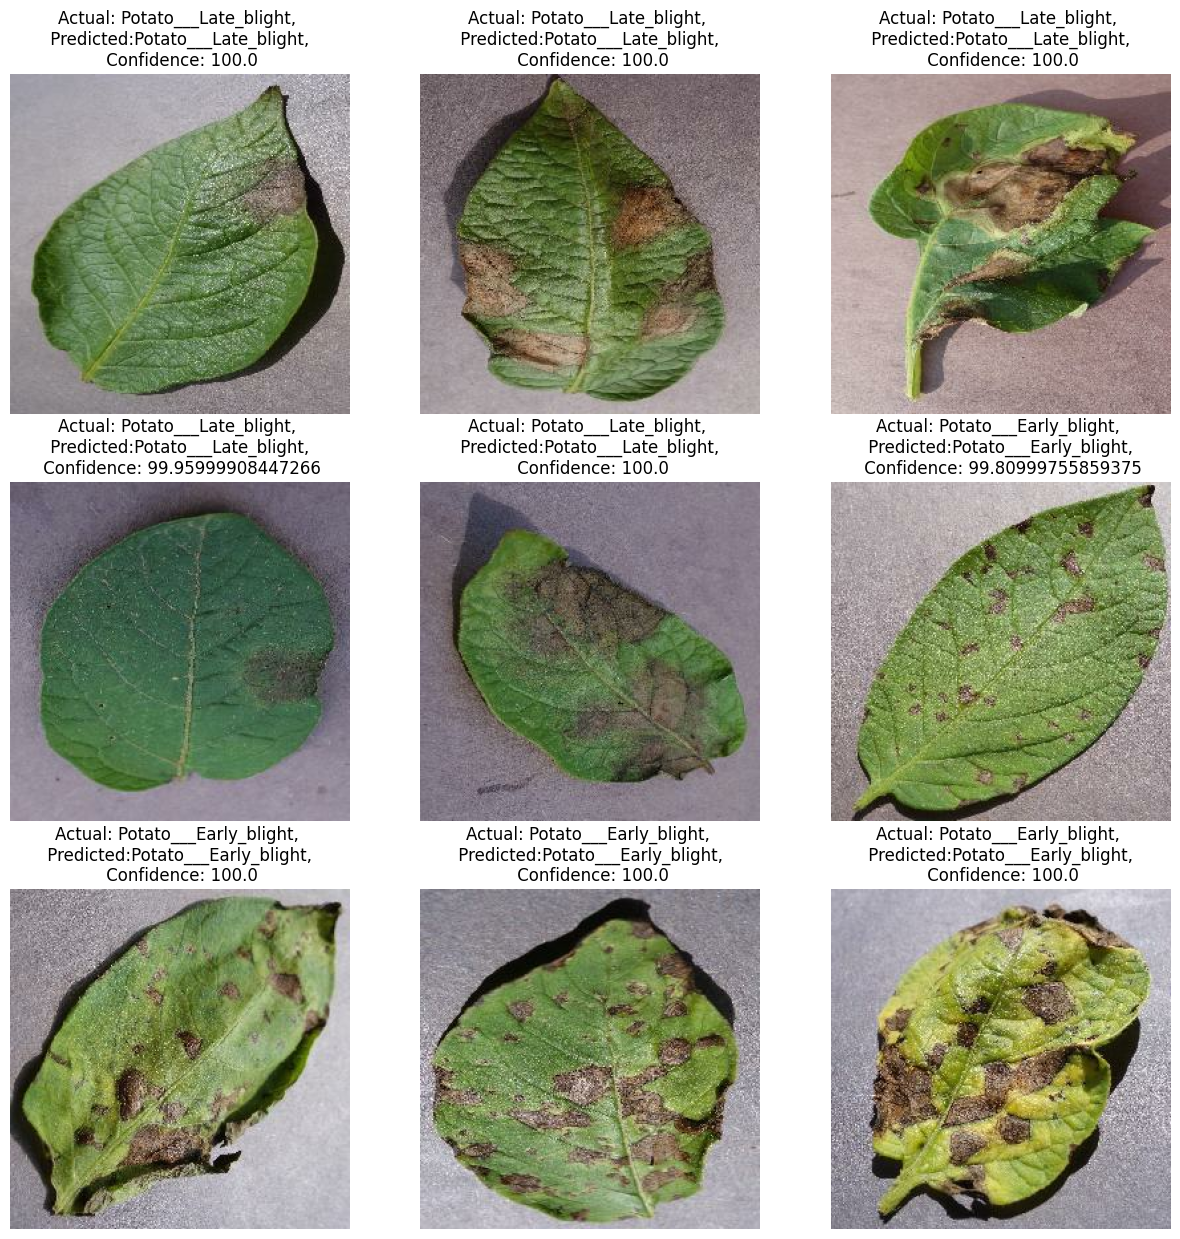

In [ ]:
plt.figure(figsize=(15, 15))

for images, labels in test_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i+1)
    plt.imshow(images[i].numpy().astype('uint8'))

    predicted_class, confidence = predict(model, images[i].numpy())
    actual_class = class_names[labels[i]]

    plt.title(f"Actual: {actual_class}, \n Predicted:{predicted_class}, \n Confidence: {confidence}")
    plt.axis('off')

In [ ]:
model_version = 1
model.save('potato_disease_classifier_3.keras')

NameError: name 'model' is not defined

In [ ]:
# First check what Colab is using — run this in Colab
import keras, tensorflow as tf
print(keras.__version__)
print(tf.__version__)

3.13.2
2.19.0
